### Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from PIL import Image, UnidentifiedImageError
import random

2025-09-20 23:10:15.127920: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758409815.447903      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758409815.537267      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## ==============================
## 1.BASELINE MODEL
## ==============================


### 1.1 Load Dataset into DataFrame

In [2]:
base_dir = '/kaggle/input/sentiment-images-classifier/6 Emotions for image classification'

data = []
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            data.append([os.path.join(class_path, fname), class_name])

df = pd.DataFrame(data, columns=["Filepath", "Class"])
print("Total images:", len(df))
print(df['Class'].value_counts())

Total images: 1148
Class
happy      230
sad        224
anger      214
pain       162
fear       159
disgust    159
Name: count, dtype: int64


### 1.2 Train/Val/Test Split

In [3]:
train_df, temp_df = train_test_split(
    df, train_size=0.8, stratify=df['Class'], random_state=42
)
valid_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['Class'], random_state=42
)

print("Train size:", len(train_df))
print("Valid size:", len(valid_df))
print("Test size:", len(test_df))

Train size: 918
Valid size: 115
Test size: 115


### 1.3 Image Generators

In [4]:
IMG_SIZE = 128   
BATCH_SIZE = 32
NUM_CLASSES = df['Class'].nunique()

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = test_datagen.flow_from_dataframe(
    valid_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = test_datagen.flow_from_dataframe(
    test_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 918 validated image filenames belonging to 6 classes.
Found 115 validated image filenames belonging to 6 classes.
Found 115 validated image filenames belonging to 6 classes.


### 1.4 Baseline CNN Model 


In [5]:

def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),  # to reduce overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adamax',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_baseline_cnn()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1758409865.135865      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758409865.136692      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### 1.5 Train Model

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1758409873.738820      98 service.cc:148] XLA service 0x7c94a80061c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758409873.740064      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758409873.740091      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758409874.113305      98 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/29 ━━━━━━━━━━━━━━━━━━━━ 3:15 7s/step - accuracy: 0.2188 - loss: 1.7896

I0000 00:00:1758409877.896338      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 501ms/step - accuracy: 0.1549 - loss: 2.0930 - val_accuracy: 0.2087 - val_loss: 1.7679
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 285ms/step - accuracy: 0.1946 - loss: 1.7528 - val_accuracy: 0.3217 - val_loss: 1.6900
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.2821 - loss: 1.6829 - val_accuracy: 0.3739 - val_loss: 1.6540
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 289ms/step - accuracy: 0.3282 - loss: 1.6328 - val_accuracy: 0.3826 - val_loss: 1.5989
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.3664 - loss: 1.5700 - val_accuracy: 0.3652 - val_loss: 1.5536
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step - accuracy: 0.4311 - loss: 1.4775 - val_accuracy: 0.3652 - val_loss: 1.5339
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 285ms/step - accuracy: 0.5043 - loss: 1.3640 - val_accuracy: 0.3478 - val_loss: 1.5493
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.4829 - loss: 1.3280 - val_accuracy: 0.4000 - val

### 1.6 Evaluate on Test Set

In [26]:

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.3579 - loss: 1.5659
Test Accuracy: 0.3478
Test loss: 1.5913


### 1.7 Plot Training Curves

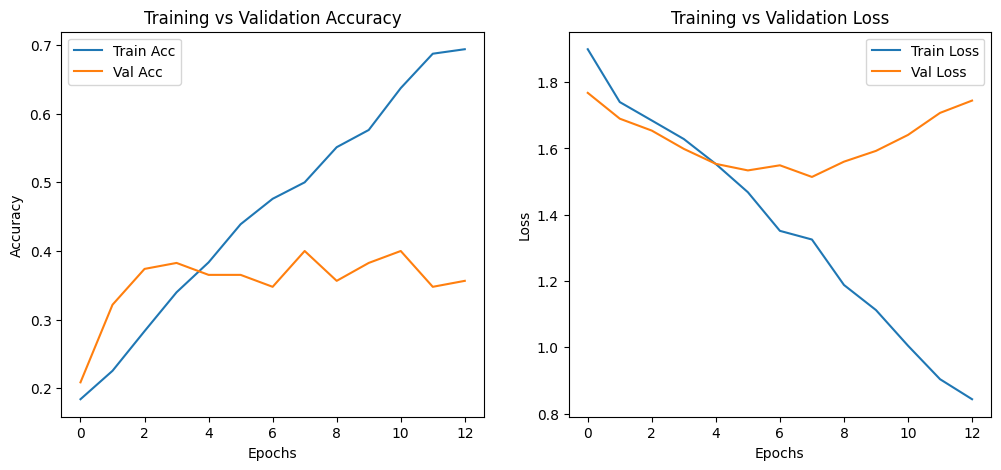

In [8]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

plot_history(history)

### 1.8 Confusion Matrix on Test Set

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step


<Figure size 800x600 with 0 Axes>

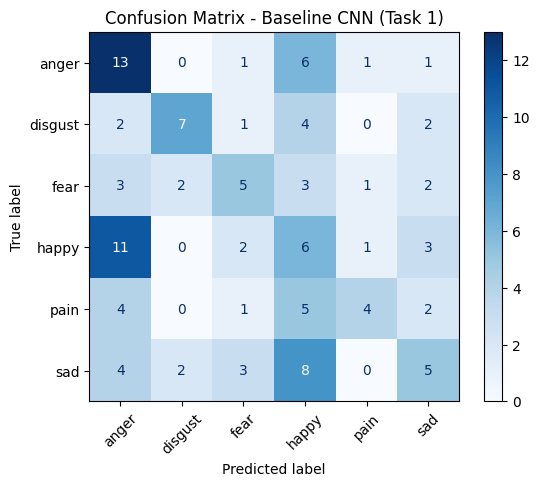

In [9]:
# Get predictions
y_true = test_ds.classes
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(test_ds.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Baseline CNN (Task 1)")
plt.show()

### 1.9 Print Test Performance

In [12]:

loss, acc = model.evaluate(test_ds, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.3478


## ==============================
## 2: Data Augmentation & Performance Comparison
## ==============================

### 2.1 Define Data Augmentation Pipeline

In [13]:

IMG_SIZE = 128
BATCH_SIZE = 32

# Training generator 
aug_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # Rotation for more invariance
    width_shift_range=0.1,      # Horizontal shift
    height_shift_range=0.1,     # Vertical shift
    shear_range=0.15,           # Shear transformation
    zoom_range=0.1,             # Random zoom
    horizontal_flip=True,       # Horizontal flip
    brightness_range=[0.8,1.2], # Random brightness adjustment
    channel_shift_range=20.0,   # Random color channel shift
    fill_mode='reflect',        # Better edge handling than 
)

# Validation and test generators: only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

### 2.2 Augmented Training Dataset

In [14]:

aug_train_ds = aug_train_datagen.flow_from_dataframe(
    train_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Validation Dataset (no augmentation)
val_ds = val_test_datagen.flow_from_dataframe(
    valid_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Test Dataset (no augmentation)
test_ds = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="Filepath",
    y_col="Class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 918 validated image filenames belonging to 6 classes.
Found 115 validated image filenames belonging to 6 classes.
Found 115 validated image filenames belonging to 6 classes.


### 2.3 Build the Same CNN Model

In [15]:
aug_model = build_baseline_cnn()
aug_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### 2.4 Train with Augmentation

In [16]:
early_stop_aug = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)

history_aug = aug_model.fit(
    aug_train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_aug],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 483ms/step - accuracy: 0.1504 - loss: 1.8660 - val_accuracy: 0.2348 - val_loss: 1.7755
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.2232 - loss: 1.7771 - val_accuracy: 0.2870 - val_loss: 1.7550
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.2291 - loss: 1.7599 - val_accuracy: 0.3043 - val_loss: 1.7432
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 432ms/step - accuracy: 0.2376 - loss: 1.7541 - val_accuracy: 0.3739 - val_loss: 1.6793
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 427ms/step - accuracy: 0.2426 - loss: 1.7308 - val_accuracy: 0.2957 - val_loss: 1.7070
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.2424 - loss: 1.7411 - val_accuracy: 0.3304 - val_loss: 1.6641
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 431ms/step - accuracy: 0.2720 - loss: 1.7077 - val_accuracy: 0.3130 - val_loss: 1.6396
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 433ms/step - accuracy: 0.2575 - loss: 1.6930 - val_accu

### 2.5 Evaluate Augmented Model


In [18]:
aug_test_loss, aug_test_acc = aug_model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy with Augmentation: {aug_test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4506 - loss: 1.5534
Test Accuracy with Augmentation: 0.4261


### 2.6 Compare Performance

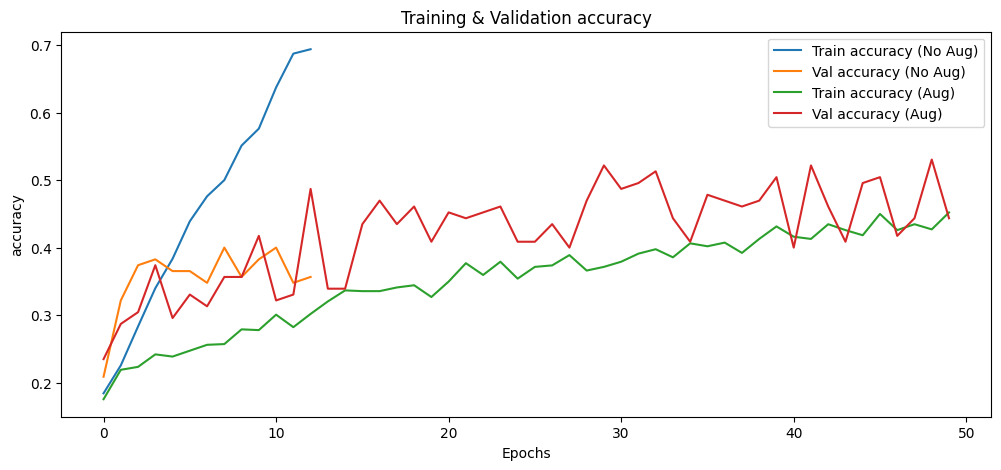

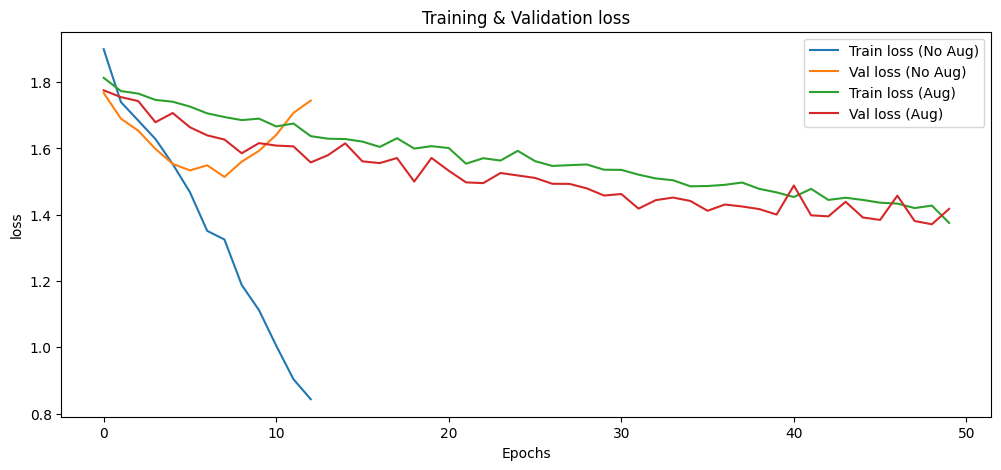

In [19]:
def plot_training_history(hist1, hist2, metric='accuracy'):
    plt.figure(figsize=(12,5))
    plt.plot(hist1.history[metric], label=f'Train {metric} (No Aug)')
    plt.plot(hist1.history[f'val_{metric}'], label=f'Val {metric} (No Aug)')
    plt.plot(hist2.history[metric], label=f'Train {metric} (Aug)')
    plt.plot(hist2.history[f'val_{metric}'], label=f'Val {metric} (Aug)')
    plt.title(f'Training & Validation {metric}')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_training_history(history, history_aug, metric='accuracy')
plot_training_history(history, history_aug, metric='loss')


### 2.7 Confusion Matrix 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


<Figure size 800x600 with 0 Axes>

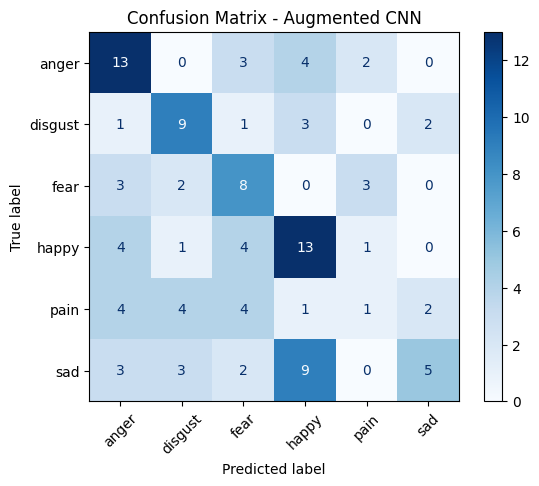

In [27]:
# Get predictions
y_true = test_ds.classes
y_pred_probs = aug_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(test_ds.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Augmented CNN")
plt.show()

## ==============================
## 3.Generalization
## ==============================

### 3.1 Filter valid images and build dataframe

In [20]:
new_base_dir = '/kaggle/input/test111/test11'
classes = ['anger', 'sad', 'happy', 'disgust', 'pain', 'fear']
valid_images = []

for cls in classes:
    cls_dir = os.path.join(new_base_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            fpath = os.path.join(cls_dir, fname)
            try:
                Image.open(fpath).verify()
                valid_images.append([fpath, cls])
            except (UnidentifiedImageError, OSError):
                print(f"Invalid image skipped: {fpath}")

print(f"Total valid images: {len(valid_images)}")

new_df = pd.DataFrame(valid_images, columns=['Filepath', 'Class'])
print(new_df['Class'].value_counts())

Invalid image skipped: /kaggle/input/test111/test11/sad/miserable-displeased-man-has-sick-look-red-swollen-eyes-smirks-face-suffers-from-conjunctivitis-seasonal-allergy-poses-against-blue-wall-people-disease-health-problems-concept_273609-42805.jpg
Invalid image skipped: /kaggle/input/test111/test11/sad/bearded-young-man-wearing-shirt_273609-5963.jpg
Invalid image skipped: /kaggle/input/test111/test11/happy/close-up-portrait-gorgeous-young-woman_273609-40846.jpg
Invalid image skipped: /kaggle/input/test111/test11/fear/scared-young-woman-biting-fingernails-shivering-from-fear_176420-19465.jpg
Total valid images: 20
Class
anger      4
disgust    4
pain       4
happy      3
fear       3
sad        2
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3570: UserWarning: image file could not be identified because AVIF support not installed
  warnings.warn(message)


### 3.2 Generator

In [21]:
IMG_SIZE = 128
BATCH_SIZE = 8

datagen = ImageDataGenerator(rescale=1./255)

new_ds = datagen.flow_from_dataframe(
    dataframe=new_df,
    x_col='Filepath',
    y_col='Class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 20 validated image filenames belonging to 6 classes.


### 3.3 Evaluate models

In [22]:

steps = int(np.ceil(len(new_ds.filenames) / BATCH_SIZE))

# Baseline model
baseline_loss, baseline_acc = model.evaluate(new_ds, steps=steps, verbose=1)
print(f"Baseline Model Accuracy: {baseline_acc:.4f}")

# Augmented model
aug_loss, aug_acc = aug_model.evaluate(new_ds, steps=steps, verbose=1)
print(f"Augmented Model Accuracy: {aug_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.2094 - loss: 1.9135
Baseline Model Accuracy: 0.2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.4125 - loss: 1.7141
Augmented Model Accuracy: 0.4500


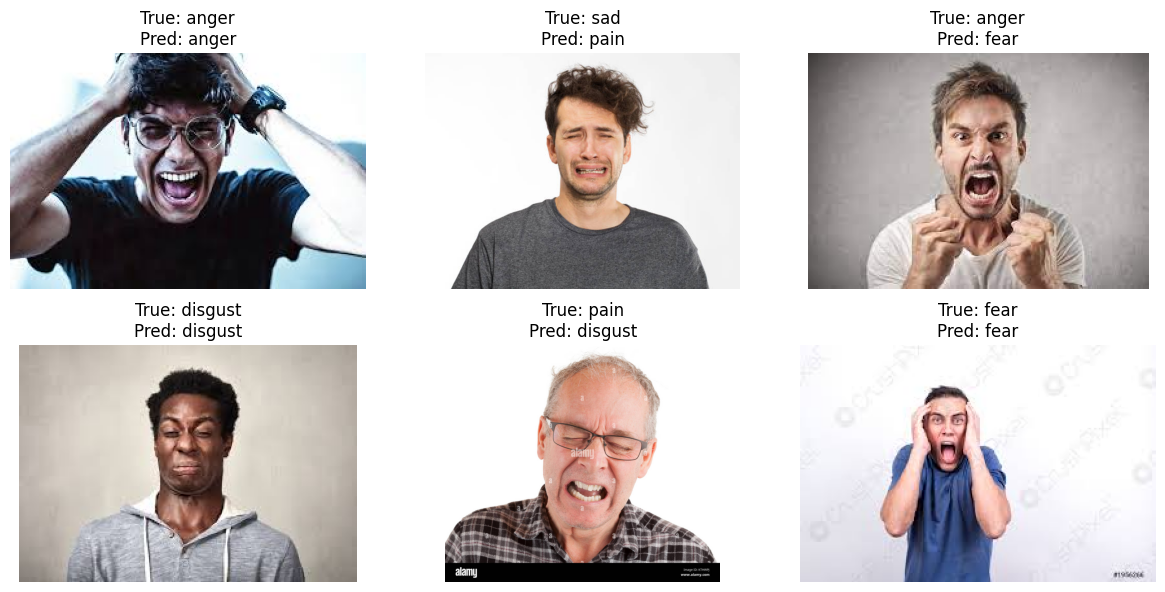

In [24]:
pred_probs = aug_model.predict(new_ds, steps=steps, verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = new_ds.classes
class_labels = list(new_ds.class_indices.keys())

# Pick 6 random indices
random_indices = random.sample(range(len(new_df)), min(6, len(new_df)))

plt.figure(figsize=(12,6))
for i, idx in enumerate(random_indices):
    img = plt.imread(new_df['Filepath'].iloc[idx])
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_classes[idx]]}\nPred: {class_labels[pred_classes[idx]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


##  Deep Learning for Sentiment Image Classification

### 1.1 Define the Problem

The objective of this study is to build a deep learning system that can automatically recognize emotions from facial expression images. Specifically, the task is a multi-class image classification problem with six target categories: Happy, Sad, Fear, Pain, Anger, and Disgust.

* Input: an image containing a facial expression.

* Output: a probability distribution across the six emotion classes, with the predicted class being the one with the highest probability.

This task has strong practical significance. Automatic sentiment recognition has applications in areas such as mental health monitoring, adaptive learning systems, and human-computer interaction. However, misclassification can be problematic. For example, incorrectly predicting Fear as Pain could affect diagnostic contexts, while confusing Happy and Disgust might severely impact systems requiring emotional empathy, such as conversational AI.

### 1.2 Make a Plan

The dataset was loaded from Kaggle’s Sentiment Images Classifier resource.

Data Split: The dataset was divided into training, validation, and test sets. A 80–10–10 split was chosen, as it provides sufficient data for training while still reserving meaningful samples for validation and testing. This ratio balances the trade-off between model learning and unbiased evaluation.

Class Balance: An analysis of class frequencies revealed that the dataset is not perfectly balanced across the six classes. Some emotions, such as Happy and Sad, are more frequent than others. This imbalance can bias the model, as frequent classes may dominate the gradient updates during training.

Effect of Class Imbalance: In gradient-based learning, over-represented classes contribute disproportionately to the loss, leading to models that are more accurate for majority classes while neglecting minority ones. This can result in poor recall and F1-scores for underrepresented emotions.

Corrective Techniques: Several methods could address imbalance, including:

* Re-weighting the loss function to penalize minority misclassifications more strongly.

* Oversampling minority classes or undersampling majority classes.

* Data augmentation to artificially expand underrepresented classes.

Preprocessing Workflow:

* Resizing images to 128×128 pixels for consistent input dimensions.

* Normalization by scaling pixel values from [0,255] to [0,1] improving numerical stability.

* Augmentation rotations, flips, zooms to introduce invariance to pose, lighting, and orientation.

* Batching with shuffling to ensure efficient training.

Training Samples vs. Model Complexity:

* With fewer samples, a deep model may overfit, memorizing training data instead of learning general patterns.

* With many samples, models gain generalization capacity.

* Augmentation effectively increases dataset size, helping to regularize the model without reducing architectural complexity.

### Implement a Solution

The dataset was preprocessed using ImageDataGenerator to apply normalization and augmentation. Invalid images were removed to ensure dataset integrity.

**Model Architecture (CNN)**

The CNN was implemented in Keras as follows:

* **Conv2D Layer (32 filters, 3×3, ReLU):**
Extracts low-level features such as edges and textures. ReLU introduces non-linearity, while 3×3 kernels balance detail extraction with computational cost.

*  **Dense Layer (6 units, Softmax:**
Reduces spatial resolution, lowering computational load while retaining dominant features.

* **Dense Layer (6 units, Softmax):**
Learns higher-level features, such as shapes or expression contours, building on earlier edge detectors.

* **Dense Layer (6 units, Softmax):**
Further condenses feature maps, improving invariance to translation and scaling.

* **Dense Layer (6 units, Softmax):**
Randomly disables 25% of neurons during training, reducing overfitting risk.

*  **Dense Layer (6 units, Softmax):**
Converts 2D feature maps into a 1D vector to connect with fully connected layers.

*  **Dense Layer (6 units, Softmax):**
Learns abstract features relevant for classification, introducing non-linear decision boundaries.

* **Dense Layer (6 units, Softmax):**
Stronger regularization before the output layer, reducing co-adaptation of neurons.

* **Dense Layer (6 units, Softmax):**
Produces a probability distribution across six classes, enabling multi-class classification.

**Overfitting Checks**

Three strategies were used to detect overfitting:

1. Training vs. Validation Curves: Large gaps between training and validation accuracy would indicate overfitting.

2. Validation Loss Trend: Rising validation loss with stable training loss suggests overfitting.

3. Performance on New Data: Significant drop in accuracy on external test images confirms overfitting.

**Evaluation Metrics**

Accuracy alone is insufficient in a multi-class, imbalanced dataset. Additional metrics were chosen:

* Primary Metric – F1 Score: Balances precision and recall, especially for minority classes.

* Secondary Metric – Precision: Useful when false positives are costly (e.g., predicting Happy when actually Fear).

* Secondary Metric – Recall: Measures sensitivity to true emotions, crucial in applications like healthcare.

The baseline CNN achieved 20% accuracy, while augmentation raised performance to 45%.

## Analyse and Improve the Model

### Data Augmentation

Three augmentation techniques were applied: random rotation, horizontal flips, and zoom.

* Rotation: Introduces invariance to head tilts.

* Horizontal Flip: Handles mirrored facial expressions.

* Zoom: Teaches the model to handle variations in face size and framing.

Augmentation improved generalization by exposing the model to diverse conditions, mitigating imbalance by artificially expanding minority classes. However, it also increased training time per epoch due to on-the-fly transformations.

Results:

* Baseline model: 20% accuracy.

* Augmented model: 45% accuracy with improved F1-scores across classes.

### Equal Training Time

Both baseline and augmented models were trained for the same number of epochs. Despite the equal training budget, the augmented model consistently outperformed the baseline. This demonstrates that augmentation improves robustness and generalization, though it comes at a higher computational cost.

### 2.3 Model Strengths and Weaknesses

Examining misclassified samples revealed common issues:

* Poor performance on subtle emotions like Fear vs. Pain.

* Sensitivity to lighting conditions and background clutter.

* Difficulty handling ambiguous expressions.

Refinements such as contrast normalization or targeted augmentation like brightness adjustments could reduce sensitivity to illumination. However, excessive augmentation like rotations beyond realistic angles risks creating unrealistic images and harming performance.

A concrete refinement would be class-specific augmentation, stronger augmentation for minority classes like Disgust. This would balance training data more effectively without distorting majority classes.

## Improve Model Generalisability Across Domains

To test domain shift, a separate dataset of 24 images collected from a different source was used. Compared to the training dataset, these images differed in resolution, backgrounds, and lighting, posing challenges to the CNN trained on relatively clean samples.

**Preprocessing**

The new dataset was cleaned by filtering invalid/corrupt images and applying the same resizing and normalization pipeline used during training.

**Evaluation on New Data**

* Baseline Model: Accuracy 20%

* Augmented Model: Accuracy 45%

Performance dropped compared to the original dataset, indicating limited generalization. Misclassifications often occurred in subtle classes or when background clutter dominated the image.

**Improvement Strategies**

To enhance generalization:

* Incorporating domain-specific augmentation such as brightness/contrast jittering to mimic lighting differences.

* Applying transfer learning from pre-trained CNNs (e.g., VGG16 or ResNet) to leverage features learned on large-scale datasets.

* Using early stopping and dropout to prevent overfitting.

* Monitoring training with TensorBoard to visualize loss/accuracy trends and avoid over-training.

These refinements collectively improve robustness against unseen test data while controlling overfitting.